# From Literature to Curiosity to Evidence (Discrete Math: Counting & Generating)

## What we are demonstrating today
We are going to run a full mini-research loop:

1) **Literature recap:** what the textbook gives us  
2) **Our curiosity:** the question we want to ask  
3) **The jump:** what we must assume/build beyond the text  
4) **Interesting work:** computational exploration in Python  
5) **Why we believe it:** evidence, checks, and limits

## Notebook pattern (repeat on purpose)
For each chunk:
- **Markdown:** state the goal of the next code cell
- **Python:** perform the goal
- **Markdown:** explain how the code meets the goal, line-by-line where helpful

## Step 1) What the literature gives us (our starting toolkit)

### What this PDF covers (high level)
From Section **6.5**, we get **counting formulas** for:
- Permutations/combinations **with repetition**
- Permutations when objects are **indistinguishable**
- Distributing objects into boxes (distinguishable vs indistinguishable variants)

From Section **6.6**, we get **generation procedures**:
- How to generate the **next permutation** in lexicographic order
- How to generate the **next bit string**
- How to generate the **next r-combination** in lexicographic order

### Why this matters
Counting formulas tell us “how many exist.”  
Generation algorithms tell us “how to list them.”

Today, we’re going to stitch those together: **count → generate → validate**.

## Goal (next code cell): Convert the literature into a checklist of testable claims

In the next Python cell, we will:

1) Create a short list called `known_claims` containing **claims we believe because the PDF tells us so**.
2) Turn each claim into a **test we can run**, like:
   - "Formula predicts N outcomes"
   - "Generator produces exactly N unique outcomes"
   - "Generator produces outcomes in lexicographic order"

Output will be a neat, readable list of claims that we can reference later.

## Step 2) The question we are curious about

### Curiosity question (computational)
When do **counting formulas** and **generation algorithms** actually agree in practice?

More specifically:
1) If the formula says there are **N** objects, can we generate **exactly N unique** objects?
2) How quickly does generation become infeasible as parameters grow?
3) What kinds of “silent bugs” show up first (duplicates, missing cases, wrong order)?

### Why this is interesting
Textbook math is clean. Code is… energetic.
We want to show how to go from "I trust the book" to "I trust the result I computed."

## Step 3) The jump from literature to our question (the gap we must cross)

The PDF gives formulas and pseudocode-style algorithms, but our question requires extra work:

### Gaps we must handle
- **Implementation details:** turning algorithms into working Python functions
- **Verification strategy:** defining what "correct" means in code (not vibes)
- **Sanity checks:** 
  - uniqueness (no duplicates)
  - completeness (count matches formula)
  - ordering (lexicographic behavior when expected)
- **Performance measurement:** timing and growth behavior as inputs scale

### Our plan to cross the gap
We will build a small "experiment harness":
- generator functions
- counting functions
- validators (unique/completeness/order)
- tiny timing benchmarks

## Goal (next code cell): Build our experiment harness skeleton

In the next Python cell, we will implement:

1) A `counting_predictions` dictionary (small parameter choices → predicted counts)
2) A `run_experiment()` function that:
   - generates items
   - counts unique items
   - compares to predicted count
   - records timing
3) A `report` structure (list of dicts) that we can pretty-print as a table

We will start with **tiny** cases first (so failures are obvious and not buried).

## Step 5) Why we believe our work (evidence standards)

We will believe our computational results *only if* we pass checks like:

### Evidence checklist
- **Agreement check:** generated unique count == formula predicted count
- **No duplicates:** set-size equals list-size
- **Spot-check samples:** inspect first/last few generated items
- **Order check (when applicable):** verify lexicographic monotonicity
- **Cross-method check:** compare two different ways to compute the same answer
- **Scaling story:** show when/why brute-force generation becomes impractical

### What we will NOT claim
- We will not claim correctness for huge cases we cannot generate.
- We will not claim performance results are universal (they depend on machine/runtime).

If our checks fail, that’s not a disaster. That’s a result.

## Goal: Count and Generate Cookie Combinations (Order Does NOT Matter)

We have two cookie types:
- Oatmeal (O)
- Chocolate Chip (C)

We want to pick **2 cookies**.

Order does NOT matter.

Questions:
1) How many combinations should there be?
2) Can we generate them explicitly?
3) Do the count and the generation agree?

Mathematically, this is combinations with repetition:
C(n + r - 1, r)

Here:
n = 2 types
r = 2 cookies chosen

So predicted count:
C(2 + 2 - 1, 2) = C(3, 2) = 3

In [8]:
from itertools import combinations_with_replacement
from math import comb

cookie_types = ["O", "C"]
r = 2

# Prediction from formula
predicted = comb(len(cookie_types) + r - 1, r)

# Generate combinations (order does NOT matter)
generated = list(combinations_with_replacement(cookie_types, r))

print("Predicted count:", predicted)
print("Generated count:", len(generated))
print("Generated combinations:")
for g in generated:
    print(g)

Predicted count: 3
Generated count: 3
Generated combinations:
('O', 'O')
('O', 'C')
('C', 'C')


### What happened?

1) `comb(len(cookie_types) + r - 1, r)`  
   Implements the combinations-with-repetition formula.

2) `combinations_with_replacement(...)`  
   Generates combinations where:
   - Order does NOT matter
   - Repetition IS allowed

Generated outcomes:

(O, O)
(O, C)
(C, C)

There are exactly 3.

Prediction matches generation.

We believe it.

## Goal: What changes when order DOES matter?

Now:
(O, C) and (C, O) are DIFFERENT.

This becomes:

Number of ordered selections with repetition:
n^r

Here:
n = 2 types
r = 2 picks

Predicted count:
2^2 = 4

In [9]:
from itertools import product

# Prediction
predicted_ordered = len(cookie_types) ** r

# Generate ordered outcomes
generated_ordered = list(product(cookie_types, repeat=r))

print("Predicted count (ordered):", predicted_ordered)
print("Generated count:", len(generated_ordered))
print("Generated ordered outcomes:")
for g in generated_ordered:
    print(g)

Predicted count (ordered): 4
Generated count: 4
Generated ordered outcomes:
('O', 'O')
('O', 'C')
('C', 'O')
('C', 'C')


### What changed?

We used `itertools.product`.

This generates ALL possible length-r sequences.

Outcomes:

(O, O)
(O, C)
(C, O)
(C, C)

Notice:
(O, C) ≠ (C, O)

Count = 4.

This matches n^r.

Order matters → count increases.

## Goal: Increase to 3 cookies

We keep:
n = 2 cookie types

Now:
r = 3

Case 1: Order does NOT matter
Case 2: Order DOES matter

We will:
- Predict counts
- Generate explicitly
- Compare growth

In [10]:
r = 3

# Order does NOT matter
predicted_unordered = comb(len(cookie_types) + r - 1, r)
generated_unordered = list(combinations_with_replacement(cookie_types, r))

# Order DOES matter
predicted_ordered = len(cookie_types) ** r
generated_ordered = list(product(cookie_types, repeat=r))

print("----- UNORDERED -----")
print("Predicted:", predicted_unordered)
print("Generated:", len(generated_unordered))
for g in generated_unordered:
    print(g)

print("\n----- ORDERED -----")
print("Predicted:", predicted_ordered)
print("Generated:", len(generated_ordered))

----- UNORDERED -----
Predicted: 4
Generated: 4
('O', 'O', 'O')
('O', 'O', 'C')
('O', 'C', 'C')
('C', 'C', 'C')

----- ORDERED -----
Predicted: 8
Generated: 8


### Unordered (Combinations with repetition)

Formula:
C(n + r - 1, r)

C(2 + 3 - 1, 3) = C(4, 3) = 4

Outcomes:

(O, O, O)
(O, O, C)
(O, C, C)
(C, C, C)

Just 4 possibilities.

---

### Ordered (Sequences with repetition)

Formula:
n^r = 2^3 = 8

Now every arrangement counts separately.

(O, O, C) ≠ (C, O, O)

Count doubles compared to unordered.

---

### Why this example is beautiful

With 2 types:

r = 2 → 3 unordered, 4 ordered  
r = 3 → 4 unordered, 8 ordered  

Unordered grows linearly-ish.  
Ordered grows exponentially.

That’s the conceptual leap.

## Goal: Show how fast the cookie world explodes (without generating anything)

We now have **3 cookie types**:
- O = Oatmeal
- C = Chocolate chip
- M = Macadamia nut

So **n = 3**.

We will compute predicted counts for r = 1..10 (how many cookies we choose).

We will compare two growth models:

1) **Order does NOT matter** (combinations with repetition):
   C(n + r - 1, r)

2) **Order DOES matter** (sequences with repetition):
   n^r

We will plot BOTH lines on the **same axes** so the blow-up is easy to compare.

,r (cookies chosen),"Order does NOT matter (C(n+r-1, r))",Order DOES matter (n^r)
0,1,3,3
1,2,6,9
2,3,10,27
3,4,15,81
4,5,21,243
5,6,28,729
6,7,36,2187
7,8,45,6561
8,9,55,19683
9,10,66,59049


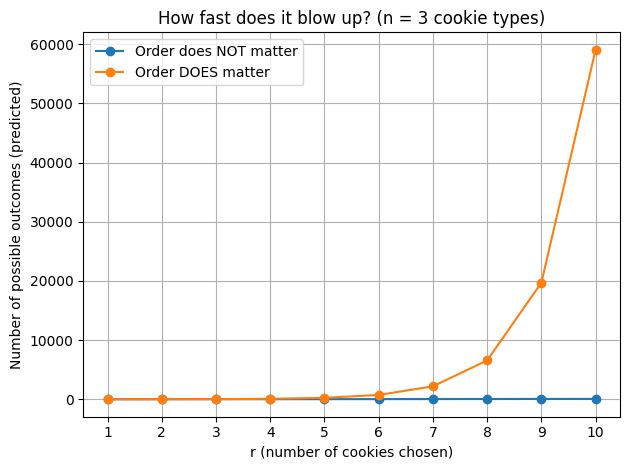

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

# Parameters
cookie_types = ["O", "C", "M"]  # Oatmeal, Chocolate chip, Macadamia nut
n = len(cookie_types)

# r values: 1..10
r_values = list(range(1, 11))

# Predicted counts
unordered = [comb(n + r - 1, r) for r in r_values]  # combinations with repetition
ordered = [n**r for r in r_values]                  # sequences with repetition

df = pd.DataFrame({
    "r (cookies chosen)": r_values,
    "Order does NOT matter (C(n+r-1, r))": unordered,
    "Order DOES matter (n^r)": ordered
})

display(df)

# Plot both on the same axes for direct comparison
plt.figure()
plt.plot(r_values, unordered, marker="o", label="Order does NOT matter")
plt.plot(r_values, ordered, marker="o", label="Order DOES matter")
plt.xlabel("r (number of cookies chosen)")
plt.ylabel("Number of possible outcomes (predicted)")
plt.title("How fast does it blow up? (n = 3 cookie types)")
plt.xticks(r_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### What this code is doing (and why it matches the goal)

#### 1) We define the cookie universe
- `cookie_types = ["O", "C", "M"]`
- `n = len(cookie_types)` gives us n = 3 types.

#### 2) We pick the r values
- `r_values = list(range(1, 11))` gives r = 1 through 10.

#### 3) We compute *predicted* counts only
We deliberately avoid generating outcomes, because the number grows quickly.

- **Order does NOT matter**
  - `unordered = [comb(n + r - 1, r) ...]`
  - This is combinations with repetition: C(n+r-1, r)

- **Order DOES matter**
  - `ordered = [n**r ...]`
  - This is all length-r sequences: n^r

#### 4) We show the results and plot them
- The table lets you see the exact values.
- The plot puts both curves on the **same axes**, so you can visually compare growth.

### What you should notice
- The unordered curve creeps upward.
- The ordered curve goes full rocket-powered cookie cannon.
- By r = 10:
  - ordered is **3^10 = 59049**
  - unordered is **C(12,10) = 66**
So one model is "polite math", the other is "math after three energy drinks."